In [19]:
#pip install facenet_pytorch

In [72]:
import os
import zipfile
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine
from facenet_pytorch import MTCNN, InceptionResnetV1
import torch
import matplotlib.image as mpimg
import heapq

In [21]:
zip = 'post-processed.zip'
path_extraido = 'dataset'
dataset_path = os.path.join(path_extraido, 'post-processed')

if not os.path.exists(path_extraido):
    with zipfile.ZipFile(zip, 'r') as zip_ref:
        zip_ref.extractall(path_extraido)

database = {}

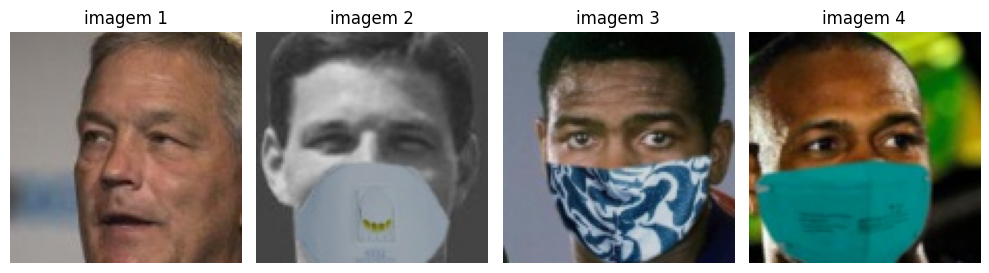

In [22]:
image_paths = []
for aux, _, files in os.walk(path_extraido):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(aux, file))
        if len(image_paths) >= 4:
            break
    if len(image_paths) >= 4:
        break

plt.figure(figsize=(10, 5))
for i, path in enumerate(image_paths):
    img = Image.open(path)
    plt.subplot(1, 4, i+1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'imagem {i+1}')
plt.tight_layout()
plt.show()

##Funções necessárias para detectar face e extrair embeddings

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

mtcnn = MTCNN(image_size=160, margin=0, min_face_size=20, device=device)
model = InceptionResnetV1(pretrained='vggface2').eval().to(device)

def get_embedding(path):
    img = Image.open(path).convert('RGB')
    face = mtcnn(img)
    if face is not None:
        face = face.unsqueeze(0).to(device)
        embedding = model(face).detach().cpu().numpy()[0]
        return embedding
    else:
        return None

def show_image(path):
    img = Image.open(path)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

In [24]:
for nome in tqdm(os.listdir(dataset_path)):
    diretorio_pessoa = os.path.join(dataset_path, nome)
    if not os.path.isdir(diretorio_pessoa):
        continue
    images = [img for img in os.listdir(diretorio_pessoa) if img.endswith(('.jpg', '.png'))]
    if not images:
        continue
    embeddings = []
    for img_name in images:
        img_path = os.path.join(diretorio_pessoa, img_name)
        embedding = get_embedding(img_path)
        if embedding is not None:
            embeddings.append(embedding)
    if embeddings:
        database[nome] = np.mean(embeddings, axis=0)

print(f"Banco de dados criado com {len(database)} pessoas.")

100%|██████████| 2996/2996 [30:56<00:00,  1.61it/s]

Banco de dados criado com 2992 pessoas.


In [64]:
marcelinho_img = 'marcelinho_no_db.jpg'
marcelinho_embedding = get_embedding(marcelinho_img)

if marcelinho_embedding is not None:
    database['marcelinho'] = marcelinho_embedding
    print("Marcelinho adicionado ao banco.")

Marcelinho adicionado ao banco.


In [65]:
marcelinho_embedding

array([ 8.09553266e-03,  2.28685327e-02, -6.91958666e-02,  4.93784137e-02,
       -3.29255126e-02, -1.33870579e-02,  3.33398692e-02,  8.38115811e-02,
        3.80695909e-02,  2.32381579e-02, -1.76244159e-03,  1.55916037e-02,
       -1.29614137e-02,  4.24721763e-02,  1.85701512e-02,  1.89581402e-02,
        6.59384429e-02, -2.82828473e-02, -3.87287438e-02,  1.69931408e-02,
        5.95942289e-02, -2.45870091e-02,  3.29349637e-02, -8.68371688e-03,
        2.88467538e-02,  3.13833496e-03, -1.43642994e-02,  2.65921131e-02,
        8.87124985e-02,  1.97552685e-02, -7.64932781e-02, -1.45527413e-02,
       -1.02741666e-01, -3.85642126e-02, -6.55032545e-02,  7.41597340e-02,
       -2.98785884e-03, -2.57918742e-02,  1.40475295e-02,  2.72024292e-02,
       -1.37968231e-02,  4.33596112e-02, -9.18480456e-02,  1.58876199e-02,
        2.43555829e-02,  3.20437774e-02,  1.10829912e-01,  4.78975363e-02,
        7.65348747e-02,  2.33988669e-02, -7.24347017e-04, -7.66370893e-02,
        3.22939865e-02, -

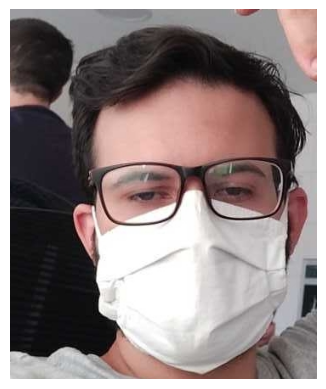

top matches:
1. James_Murdoch - Score: 0.4734
2. Makhdoom_Amin_Fahim - Score: 0.4980
3. Scott_Ritter - Score: 0.5001
4. Jesse_Harris - Score: 0.5159
5. Carla_Gugino - Score: 0.5203
6. Albert_Brooks - Score: 0.5206
7. James_Kopp - Score: 0.5217
8. Serge_Klarsfeld - Score: 0.5384
9. Ben_Lee - Score: 0.5394
10. Jason_Alexander - Score: 0.5489
11. Elvis_Costello - Score: 0.5618
12. Mikhail_Kasyanov - Score: 0.5705
13. Sheila_Fraser - Score: 0.5711
14. Brad_Gushue - Score: 0.5749
15. Bud_Selig - Score: 0.5757
16. Ben_Affleck - Score: 0.5830
17. Ruth_Dreifuss - Score: 0.5891
18. marcelinho - Score: 0.5898
19. Percy_Gibson - Score: 0.5934
20. Lars_Von_Trier - Score: 0.5962


In [76]:
marcelinho_inf_img = 'marcelinho_na_inferencia.jpg'
query_embedding = get_embedding(marcelinho_inf_img)

if query_embedding is not None:
    show_image(marcelinho_inf_img)

    scores = []

    for name, db_embedding in database.items():
        score = cosine(query_embedding, db_embedding)
        scores.append((score, name))

    top_5 = heapq.nsmallest(20, scores, key=lambda x: x[0])

    print("top matches:")
    for i, (score, name) in enumerate(top_5, 1):
        print(f"{i}. {name} - Score: {score:.4f}")

else:
    print("não foi possível detectar o rosto")

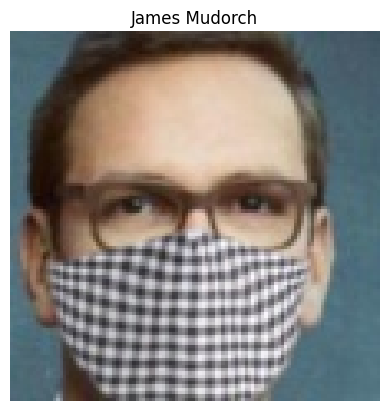

In [77]:
img_path = '/content/dataset/post-processed/James_Murdoch/James_Murdoch_0001_0000.jpg'
img = mpimg.imread(img_path)

plt.imshow(img)
plt.title("James Mudorch")
plt.axis('off')  # Remove os eixos
plt.show()

In [78]:
for name, db_embedding in database.items():
  print("\nNome: " + name)


Nome: Kirk_Ferentz

Nome: Roy_Jones_Jr

Nome: Masum_Turker

Nome: Darin_Erstad

Nome: Jon_Corzine

Nome: Zinedine_Zidane

Nome: Robert_Wagner

Nome: Jim_Tressel

Nome: Claire_Danes

Nome: Barry_Williams

Nome: Gregor_Gysi

Nome: Lauren_Hutton

Nome: Cheryl_Ford

Nome: Lucy_Liu

Nome: Marie-Josee_Croze

Nome: Jim_Edmonds

Nome: Heather_Willson

Nome: Priscilla_Presley

Nome: Jennifer_Rodriguez

Nome: David_Beckham

Nome: Hans_Blix

Nome: Dan_Duquette

Nome: Dean_Barker

Nome: Michael_Pfleger

Nome: Eve_Pelletier

Nome: Bill_Maher

Nome: John_Prescott

Nome: Richard_Gere

Nome: Zoran_Djindjic

Nome: Jean_Todt

Nome: Gorden_Tallis

Nome: Amy_Cotton

Nome: Elvis_Costello

Nome: Paul_McCartney

Nome: Deepa_Mehta

Nome: Jennifer_Tilly

Nome: Columba_Bush

Nome: Hugo_Chavez

Nome: Philippe_Noiret

Nome: George_W_Bush

Nome: Brad_Brownell

Nome: Jackie_Sherrill

Nome: Tatsuya_Fuji

Nome: Job_Cohen

Nome: Richard_Virenque

Nome: Pyar_Jung_Thapa

Nome: Antje_Buschschulte

Nome: Jeffrey_Jones

N

In [79]:
pip freeze > requirements.txt